## Benchmark Run Script (Reference)

```bash
cd /Users/RyanLandvater/Programming_Projects/FHIR_Testing
DYLD_LIBRARY_PATH=local/lib ./build/bench/bench/bench_harness --warmup-iterations 2 --iterations 10 --db "host=localhost port=5432 dbname=benchmark user=bench password=bench"
```

Optional explicit runs (same as current default):

```bash
cd /Users/RyanLandvater/Programming_Projects/FHIR_Testing
DYLD_LIBRARY_PATH=local/lib ./build/bench/bench/bench_harness --warmup-iterations 3 --iterations 10 --db "host=localhost port=5432 dbname=benchmark user=bench password=bench" --runs 20
```

```bash
PGPASSWORD=bench /opt/homebrew/Cellar/libpq/17.4/bin/psql -h localhost -p 5432 -U bench -d benchmark -c "TRUNCATE benchmark_results, benchmark_runs RESTART IDENTITY CASCADE;" && echo "Done"
```


Deprecated old command path removed. Use the benchmark DB command shown above.

# FastFHIR vs JSON-FHIR Benchmark Results

This notebook loads and analyzes benchmark results from the C++ harness.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import os
from sqlalchemy import create_engine, text

# Configuration - read from environment or use benchmark defaults
db_host = os.getenv('POSTGRES_HOST', 'localhost')
db_port = os.getenv('POSTGRES_PORT', '5432')
db_name = os.getenv('POSTGRES_DB', 'benchmark')
db_user = os.getenv('POSTGRES_USER', 'bench')
db_pass = os.getenv('POSTGRES_PASSWORD', 'bench')

db_url = f"postgresql+psycopg2://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}"
print(f"Connecting to {db_user}@{db_host}:{db_port}/{db_name}")

## Load Results from Database

In [ ]:
try:
    engine = create_engine(db_url, pool_pre_ping=True)
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    print("Connected successfully (SQLAlchemy)")
except Exception as e:
    print(f"Connection failed: {e}")
    engine = None

## Summary Statistics

In [98]:
if 'engine' in locals() and engine is not None:
    query = """
    WITH latest AS (
        SELECT MAX(run_id) AS run_id
        FROM benchmark_results
    )
    SELECT
        br.id,
        br.run_id,
        br.arm,
        br.stage,
        br.duration_ns,
        br.target_mb,
        br.patients_in_bundle,
        br.created_at
    FROM benchmark_results br
    JOIN latest l ON br.run_id = l.run_id
    ORDER BY br.target_mb, br.arm, br.stage
    """
    
    # Load only the latest run to avoid truncating larger target sizes.
    df = pd.read_sql(query, engine)

    # Normalize legacy stage labels to the current test taxonomy.
    test_name_map = {
        'stage1_serialize': 'test_1_serialize',
        'stage2_transport': 'test_2_materialize',
        'stage3_query': 'test_3_query',
        'stage3_materialize': 'test_2_materialize',
    }
    df['test'] = df['stage'].replace(test_name_map)

    # Keep notebook charts in microseconds while storing raw timings in nanoseconds.
    df['duration_us'] = df['duration_ns'].astype(float) / 1000.0

    # Throughput in records/sec; keep float dtype to avoid object arrays in plotting.
    df['records_per_second'] = np.where(
        df['duration_us'] > 0,
        (df['patients_in_bundle'] * 1_000_000.0) / df['duration_us'],
        np.nan,
    ).astype(float)
    
    # Plot all active benchmark arms, including Google FHIR protobuf arm.
    plot_arms = ['fastfhir', 'json_fhir', 'hl7v2', 'google_fhir']

    # Convenience DataFrames for manual inspection when needed.
    df_preview = df.head(20).copy()
    latest_run_id = int(df['run_id'].max()) if len(df) > 0 else None
    latest_run_df = df.copy() if len(df) > 0 else pd.DataFrame()
else:
    df = pd.DataFrame()
    df_preview = pd.DataFrame()
    latest_run_df = pd.DataFrame()
    latest_run_id = None
    plot_arms = ['fastfhir', 'json_fhir', 'hl7v2', 'google_fhir']


## Summary Statistics

In [ ]:
if 'df' in locals() and len(df) > 0:
    summary = df.groupby(['arm', 'test'])['duration_us'].agg(['mean', 'std', 'min', 'max']).round(2)
    arm_totals = df.groupby('arm')['duration_us'].agg(['sum', 'mean', 'count']).round(2)
    
    # Keep optional preview frames ready for manual review.
    summary_preview = summary.reset_index().copy()
    arm_totals_preview = arm_totals.reset_index().copy()
else:
    summary = pd.DataFrame()
    arm_totals = pd.DataFrame()
    summary_preview = pd.DataFrame()
    arm_totals_preview = pd.DataFrame()
summary_preview

## Performance Comparison - Serialization

In [ ]:
if 'df' in locals() and len(df) > 0:
    use_latest_run_only = True
    source_df = latest_run_df if use_latest_run_only and 'latest_run_df' in locals() and len(latest_run_df) > 0 else df
    test1_data = source_df[source_df['test'] == 'test_1_serialize'].copy()

    if len(test1_data) > 0:
        show_smoke_arms = False
        if not show_smoke_arms:
            test1_data = test1_data[test1_data['arm'].isin(plot_arms)].copy()

        arms = sorted(test1_data['arm'].unique())
        target_mbs = sorted(test1_data['target_mb'].unique())
        n_arms = len(arms)
        n_targets = len(target_mbs)

        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        arm_colors = {arm: colors[i] for i, arm in enumerate(arms)}

        # Keep each bin under ~70% of axis width so adjacent bins do not overlap.
        max_cluster_span = 0.70
        width = min(0.22, max_cluster_span / max(n_arms, 1))
        fig, (ax_rps, ax_dur) = plt.subplots(2, 1, figsize=(17, 10))

        # Top plot: Records per second (throughput)
        for ai, arm in enumerate(arms):
            offset = (ai - (n_arms - 1) / 2) * width
            positions = [i + 1 + offset for i in range(n_targets)]
            violin_data = [
                pd.to_numeric(
                    test1_data[(test1_data['arm'] == arm) & (test1_data['target_mb'] == mb)]['records_per_second'],
                    errors='coerce',
                ).replace([np.inf, -np.inf], np.nan).dropna().astype(float).values
                for mb in target_mbs
            ]
            valid = [(pos, d) for pos, d in zip(positions, violin_data) if len(d) >= 2]
            if valid:
                vpos, vdata = zip(*valid)
                parts = ax_rps.violinplot(list(vdata), positions=list(vpos), widths=width * 0.85,
                                      showmedians=True, showextrema=True)
                color = arm_colors[arm]
                for pc in parts['bodies']:
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
                for key in ('cmedians', 'cmaxes', 'cmins', 'cbars'):
                    parts[key].set_color(color)
                    parts[key].set_linewidth(1.5)
            ax_rps.fill_between([], [], color=arm_colors[arm], alpha=0.7, label=arm)

        ax_rps.set_xticks(range(1, n_targets + 1))
        ax_rps.set_xticklabels([f'{mb} MB' for mb in target_mbs])
        ax_rps.set_xlim(0.5, n_targets + 0.5)
        for x in range(1, n_targets):
            ax_rps.axvline(x + 0.5, color='0.85', linewidth=0.8, zorder=0)
        ax_rps.set_xlabel('Bundle Size (MB)', fontsize=12)
        ax_rps.set_ylabel('Serialization Throughput (records/sec)', fontsize=12)
        ax_rps.set_title('Test 1: Serialization Throughput', fontsize=14, fontweight='bold')
        ax_rps.legend(fontsize=11)
        ax_rps.grid(True, alpha=0.3, axis='y', which='major')
        ax_rps.set_yscale('log')
        ax_rps.minorticks_on()
        ax_rps.grid(True, alpha=0.12, axis='y', which='minor', linewidth=0.6)

        # Bottom plot: Duration (microseconds)
        for ai, arm in enumerate(arms):
            offset = (ai - (n_arms - 1) / 2) * width
            positions = [i + 1 + offset for i in range(n_targets)]
            violin_data = [
                test1_data[(test1_data['arm'] == arm) & (test1_data['target_mb'] == mb)]['duration_us'].astype(float).values
                for mb in target_mbs
            ]
            valid = [(pos, d) for pos, d in zip(positions, violin_data) if len(d) >= 2]
            if valid:
                vpos, vdata = zip(*valid)
                parts = ax_dur.violinplot(list(vdata), positions=list(vpos), widths=width * 0.85,
                                      showmedians=True, showextrema=True)
                color = arm_colors[arm]
                for pc in parts['bodies']:
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
                for key in ('cmedians', 'cmaxes', 'cmins', 'cbars'):
                    parts[key].set_color(color)
                    parts[key].set_linewidth(1.5)
            ax_dur.fill_between([], [], color=arm_colors[arm], alpha=0.7, label=arm)

        ax_dur.set_xticks(range(1, n_targets + 1))
        ax_dur.set_xticklabels([f'{mb} MB' for mb in target_mbs])
        ax_dur.set_xlim(0.5, n_targets + 0.5)
        for x in range(1, n_targets):
            ax_dur.axvline(x + 0.5, color='0.85', linewidth=0.8, zorder=0)
        ax_dur.set_xlabel('Bundle Size (MB)', fontsize=12)
        ax_dur.set_ylabel('Serialization Time (microseconds)', fontsize=12)
        ax_dur.set_title('Test 1: Serialization Duration', fontsize=14, fontweight='bold')
        ax_dur.legend(fontsize=11)
        ax_dur.grid(True, alpha=0.3, axis='y', which='major')
        ax_dur.set_yscale('log')
        ax_dur.minorticks_on()
        ax_dur.grid(True, alpha=0.12, axis='y', which='minor', linewidth=0.6)

        plt.tight_layout()
        plt.show()
    else:
        print('No test 1 serialization data found')

## Performance Comparison - Materialization

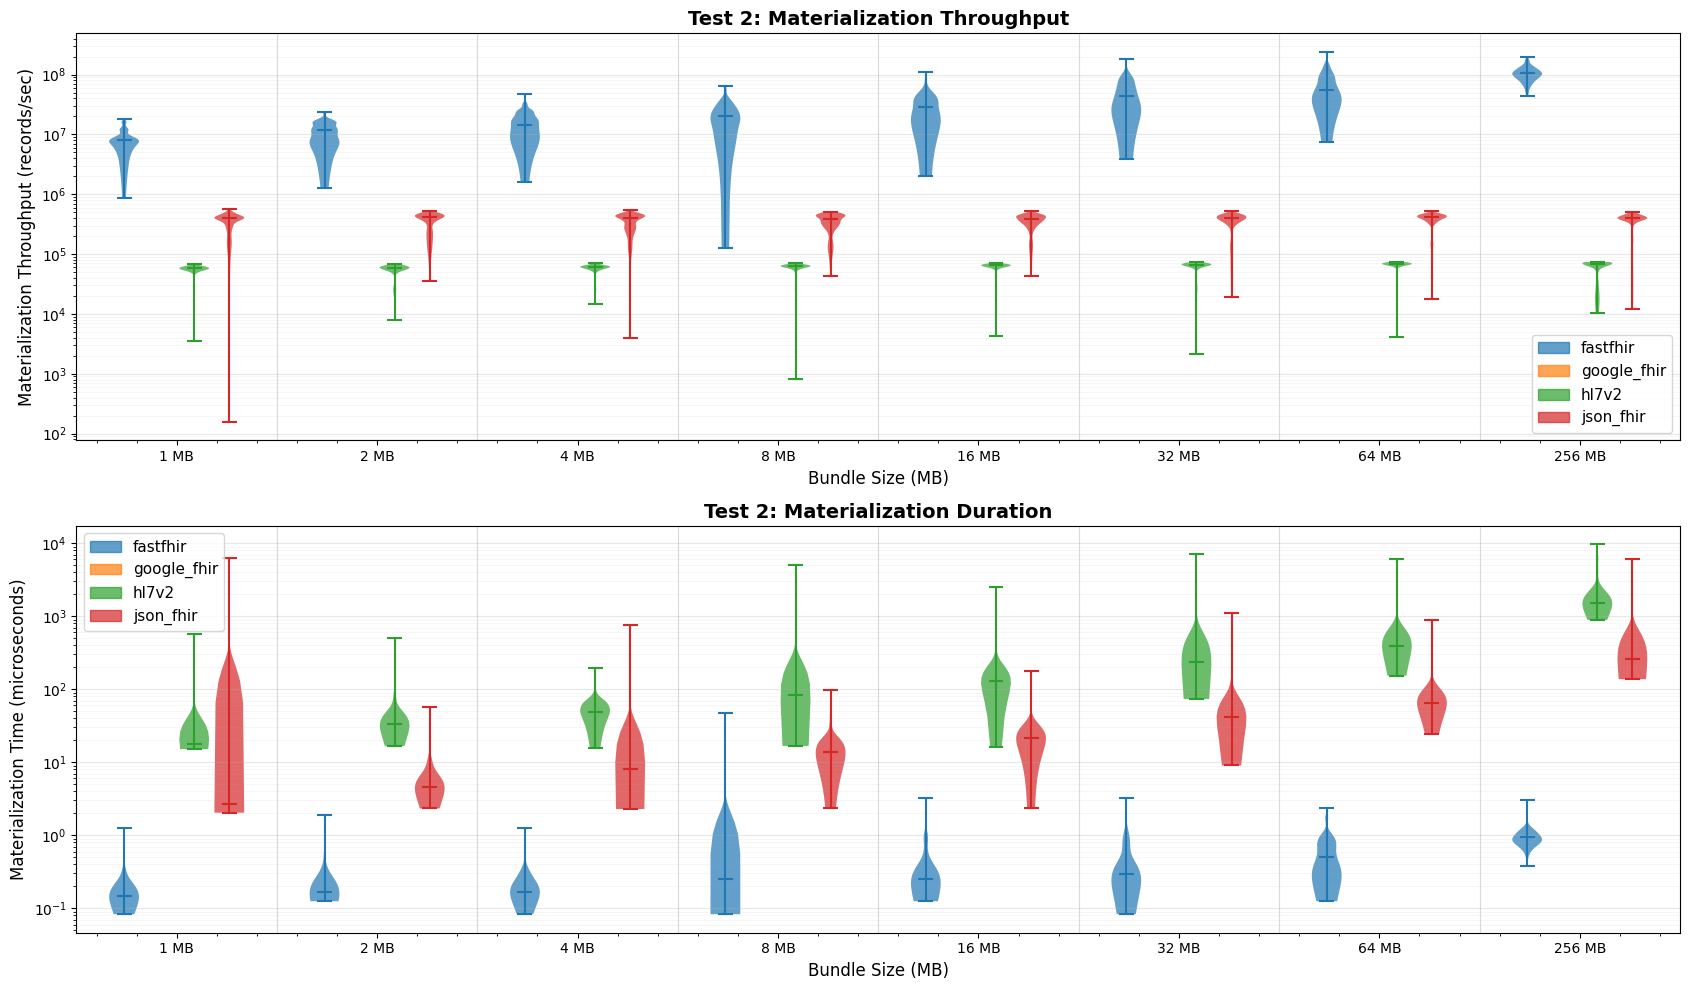

In [99]:
if 'df' in locals() and len(df) > 0:
    use_latest_run_only = True
    source_df = latest_run_df if use_latest_run_only and 'latest_run_df' in locals() and len(latest_run_df) > 0 else df
    test2_data = source_df[source_df['test'] == 'test_2_materialize'].copy()

    if len(test2_data) > 0:
        show_smoke_arms = False
        if not show_smoke_arms:
            test2_data = test2_data[test2_data['arm'].isin(plot_arms)].copy()

        arms = sorted(test2_data['arm'].unique())
        target_mbs = sorted(test2_data['target_mb'].unique())
        n_arms = len(arms)
        n_targets = len(target_mbs)

        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        arm_colors = {arm: colors[i] for i, arm in enumerate(arms)}

        # Keep each bin under ~70% of axis width so adjacent bins do not overlap.
        max_cluster_span = 0.70
        width = min(0.22, max_cluster_span / max(n_arms, 1))
        fig, (ax_rps, ax_dur) = plt.subplots(2, 1, figsize=(17, 10))

        # Top plot: Records per second (throughput)
        for ai, arm in enumerate(arms):
            offset = (ai - (n_arms - 1) / 2) * width
            positions = [i + 1 + offset for i in range(n_targets)]
            violin_data = [
                pd.to_numeric(
                    test2_data[(test2_data['arm'] == arm) & (test2_data['target_mb'] == mb)]['records_per_second'],
                    errors='coerce',
                ).replace([np.inf, -np.inf], np.nan).dropna().astype(float).values
                for mb in target_mbs
            ]
            valid = [(pos, d) for pos, d in zip(positions, violin_data) if len(d) >= 2]
            if valid:
                vpos, vdata = zip(*valid)
                parts = ax_rps.violinplot(list(vdata), positions=list(vpos), widths=width * 0.85,
                                      showmedians=True, showextrema=True)
                color = arm_colors[arm]
                for pc in parts['bodies']:
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
                for key in ('cmedians', 'cmaxes', 'cmins', 'cbars'):
                    parts[key].set_color(color)
                    parts[key].set_linewidth(1.5)
            ax_rps.fill_between([], [], color=arm_colors[arm], alpha=0.7, label=arm)

        ax_rps.set_xticks(range(1, n_targets + 1))
        ax_rps.set_xticklabels([f'{mb} MB' for mb in target_mbs])
        ax_rps.set_xlim(0.5, n_targets + 0.5)
        for x in range(1, n_targets):
            ax_rps.axvline(x + 0.5, color='0.85', linewidth=0.8, zorder=0)
        ax_rps.set_xlabel('Bundle Size (MB)', fontsize=12)
        ax_rps.set_ylabel('Materialization Throughput (records/sec)', fontsize=12)
        ax_rps.set_title('Test 2: Materialization Throughput', fontsize=14, fontweight='bold')
        ax_rps.legend(fontsize=11)
        ax_rps.grid(True, alpha=0.3, axis='y', which='major')
        ax_rps.set_yscale('log')
        ax_rps.minorticks_on()
        ax_rps.grid(True, alpha=0.12, axis='y', which='minor', linewidth=0.6)

        # Bottom plot: Duration (microseconds)
        for ai, arm in enumerate(arms):
            offset = (ai - (n_arms - 1) / 2) * width
            positions = [i + 1 + offset for i in range(n_targets)]
            violin_data = [
                test2_data[(test2_data['arm'] == arm) & (test2_data['target_mb'] == mb)]['duration_us'].astype(float).values
                for mb in target_mbs
            ]
            valid = [(pos, d) for pos, d in zip(positions, violin_data) if len(d) >= 2]
            if valid:
                vpos, vdata = zip(*valid)
                parts = ax_dur.violinplot(list(vdata), positions=list(vpos), widths=width * 0.85,
                                      showmedians=True, showextrema=True)
                color = arm_colors[arm]
                for pc in parts['bodies']:
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
                for key in ('cmedians', 'cmaxes', 'cmins', 'cbars'):
                    parts[key].set_color(color)
                    parts[key].set_linewidth(1.5)
            ax_dur.fill_between([], [], color=arm_colors[arm], alpha=0.7, label=arm)

        ax_dur.set_xticks(range(1, n_targets + 1))
        ax_dur.set_xticklabels([f'{mb} MB' for mb in target_mbs])
        ax_dur.set_xlim(0.5, n_targets + 0.5)
        for x in range(1, n_targets):
            ax_dur.axvline(x + 0.5, color='0.85', linewidth=0.8, zorder=0)
        ax_dur.set_xlabel('Bundle Size (MB)', fontsize=12)
        ax_dur.set_ylabel('Materialization Time (microseconds)', fontsize=12)
        ax_dur.set_title('Test 2: Materialization Duration', fontsize=14, fontweight='bold')
        ax_dur.legend(fontsize=11)
        ax_dur.grid(True, alpha=0.3, axis='y', which='major')
        ax_dur.set_yscale('log')
        ax_dur.minorticks_on()
        ax_dur.grid(True, alpha=0.12, axis='y', which='minor', linewidth=0.6)

        plt.tight_layout()
        plt.show()
    else:
        print('No test 2 materialization data found')

## Performance Comparison - Query

In [ ]:
if 'df' in locals() and len(df) > 0:
    use_latest_run_only = True
    source_df = latest_run_df if use_latest_run_only and 'latest_run_df' in locals() and len(latest_run_df) > 0 else df
    test3_data = source_df[source_df['test'] == 'test_3_query'].copy()

    if len(test3_data) > 0:
        show_smoke_arms = False
        if not show_smoke_arms:
            test3_data = test3_data[test3_data['arm'].isin(plot_arms)].copy()

        arms = sorted(test3_data['arm'].unique())
        target_mbs = sorted(test3_data['target_mb'].unique())
        n_arms = len(arms)
        n_targets = len(target_mbs)

        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        arm_colors = {arm: colors[i] for i, arm in enumerate(arms)}

        # Keep each bin under ~70% of axis width so adjacent bins do not overlap.
        max_cluster_span = 0.70
        width = min(0.22, max_cluster_span / max(n_arms, 1))
        fig, (ax_rps, ax_dur) = plt.subplots(2, 1, figsize=(17, 10))

        # Top plot: Records per second (throughput)
        for ai, arm in enumerate(arms):
            offset = (ai - (n_arms - 1) / 2) * width
            positions = [i + 1 + offset for i in range(n_targets)]
            violin_data = [
                pd.to_numeric(
                    test3_data[(test3_data['arm'] == arm) & (test3_data['target_mb'] == mb)]['records_per_second'],
                    errors='coerce',
                ).replace([np.inf, -np.inf], np.nan).dropna().astype(float).values
                for mb in target_mbs
            ]
            valid = [(pos, d) for pos, d in zip(positions, violin_data) if len(d) >= 2]
            if valid:
                vpos, vdata = zip(*valid)
                parts = ax_rps.violinplot(list(vdata), positions=list(vpos), widths=width * 0.85,
                                      showmedians=True, showextrema=True)
                color = arm_colors[arm]
                for pc in parts['bodies']:
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
                for key in ('cmedians', 'cmaxes', 'cmins', 'cbars'):
                    parts[key].set_color(color)
                    parts[key].set_linewidth(1.5)
            ax_rps.fill_between([], [], color=arm_colors[arm], alpha=0.7, label=arm)

        ax_rps.set_xticks(range(1, n_targets + 1))
        ax_rps.set_xticklabels([f'{mb} MB' for mb in target_mbs])
        ax_rps.set_xlim(0.5, n_targets + 0.5)
        for x in range(1, n_targets):
            ax_rps.axvline(x + 0.5, color='0.85', linewidth=0.8, zorder=0)
        ax_rps.set_xlabel('Bundle Size (MB)', fontsize=12)
        ax_rps.set_ylabel('Query Throughput (records/sec)', fontsize=12)
        ax_rps.set_title('Test 3: Query Throughput', fontsize=14, fontweight='bold')
        ax_rps.legend(fontsize=11)
        ax_rps.grid(True, alpha=0.3, axis='y', which='major')
        ax_rps.set_yscale('log')
        ax_rps.minorticks_on()
        ax_rps.grid(True, alpha=0.12, axis='y', which='minor', linewidth=0.6)

        # Bottom plot: Duration (microseconds)
        for ai, arm in enumerate(arms):
            offset = (ai - (n_arms - 1) / 2) * width
            positions = [i + 1 + offset for i in range(n_targets)]
            violin_data = [
                test3_data[(test3_data['arm'] == arm) & (test3_data['target_mb'] == mb)]['duration_us'].astype(float).values
                for mb in target_mbs
            ]
            valid = [(pos, d) for pos, d in zip(positions, violin_data) if len(d) >= 2]
            if valid:
                vpos, vdata = zip(*valid)
                parts = ax_dur.violinplot(list(vdata), positions=list(vpos), widths=width * 0.85,
                                      showmedians=True, showextrema=True)
                color = arm_colors[arm]
                for pc in parts['bodies']:
                    pc.set_facecolor(color)
                    pc.set_alpha(0.7)
                for key in ('cmedians', 'cmaxes', 'cmins', 'cbars'):
                    parts[key].set_color(color)
                    parts[key].set_linewidth(1.5)
            ax_dur.fill_between([], [], color=arm_colors[arm], alpha=0.7, label=arm)

        ax_dur.set_xticks(range(1, n_targets + 1))
        ax_dur.set_xticklabels([f'{mb} MB' for mb in target_mbs])
        ax_dur.set_xlim(0.5, n_targets + 0.5)
        for x in range(1, n_targets):
            ax_dur.axvline(x + 0.5, color='0.85', linewidth=0.8, zorder=0)
        ax_dur.set_xlabel('Bundle Size (MB)', fontsize=12)
        ax_dur.set_ylabel('Query Time (microseconds)', fontsize=12)
        ax_dur.set_title('Test 3: Query Duration', fontsize=14, fontweight='bold')
        ax_dur.legend(fontsize=11)
        ax_dur.grid(True, alpha=0.3, axis='y', which='major')
        ax_dur.set_yscale('log')
        ax_dur.minorticks_on()
        ax_dur.grid(True, alpha=0.12, axis='y', which='minor', linewidth=0.6)

        plt.tight_layout()
        plt.show()
    else:
        print('No test 3 query data found')

## Cleanup

In [ ]:
if 'engine' in locals() and engine is not None:
    engine.dispose()
    print("Database engine disposed")